# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D , MaxPool2D , Flatten , Dense , Dropout , BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix , classification_report
import seaborn as sns

# Data Loading

In [2]:
class_names = ["T-shirt/Top","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boat"]

In [3]:
(X_train,y_train),(X_test,y_test) = fashion_mnist.load_data()

print(X_train.shape,X_test.shape)
print(y_train.shape,y_test.shape)

(60000, 28, 28) (10000, 28, 28)
(60000,) (10000,)


# Sample Image

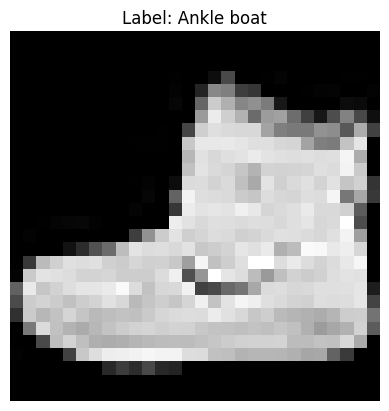

In [4]:
plt.imshow(X_train[0],cmap='gray')
plt.title(f"Label: {class_names[y_train[0]]}")
plt.axis("off")
plt.show()

# Preprocessing

In [5]:
X_train = X_train.reshape(-1,28,28,1)/255.0
X_test = X_test.reshape(-1,28,28,1)/255.0

# Build the CNN

In [6]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2)))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2)))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(10,activation='softmax'))

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,986 (464.79 KB)

 Trainable params: 118,538 (463.04 KB)

 Non-trainable params: 448 (1.75 KB)

# Compile and Train

In [7]:
early_stop=EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history=model.fit(
    X_train,y_train,
    epochs=10,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 64s 40ms/step - accuracy: 0.7959 - loss: 0.5820 - val_accuracy: 0.8055 - val_loss: 0.5648
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 41ms/step - accuracy: 0.8593 - loss: 0.3961 - val_accuracy: 0.8692 - val_loss: 0.3583
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 40ms/step - accuracy: 0.8772 - loss: 0.3414 - val_accuracy: 0.8660 - val_loss: 0.3681
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 61s 41ms/step - accuracy: 0.8875 - loss: 0.3087 - val_accuracy: 0.8806 - val_loss: 0.3327
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 59s 39ms/step - accuracy: 0.8958 - loss: 0.2862 - val_accuracy: 0.8861 - val_loss: 0.3210
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 60s 40ms/step - accuracy: 0.9066 - loss: 0.2625 - val_accuracy: 0.8857 - val_loss: 0.3256
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 59s 39ms/step - accuracy: 0.9124 - loss: 0.2445 - val_accuracy: 0.8939 - val_loss: 0.2986
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 40ms/step - accuracy: 0.9180 -

# Plot Result

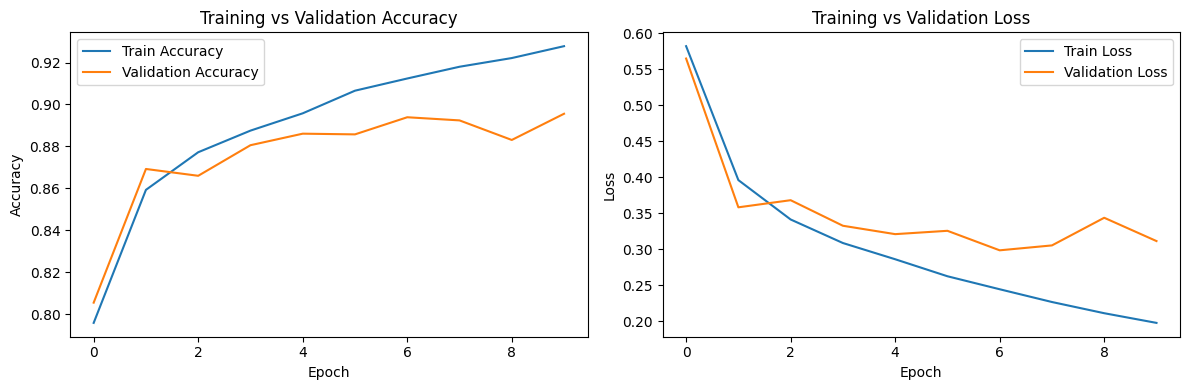

In [8]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate on the test data

In [9]:
test_loss,test_acc = model.evaluate(X_test,y_test)
print(f"Test Accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8922 - loss: 0.3120
Test Accuracy: 0.8922


# Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
              precision    recall  f1-score   support

 T-shirt/Top       0.88      0.82      0.85      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.82      0.85      0.83      1000
       Dress       0.88      0.91      0.90      1000
        Coat       0.85      0.79      0.82      1000
      Sandal       0.98      0.97      0.97      1000
       Shirt       0.68      0.74      0.71      1000
     Sneaker       0.97      0.92      0.94      1000
         Bag       0.97      0.98      0.97      1000
  Ankle boat       0.92      0.98      0.95      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



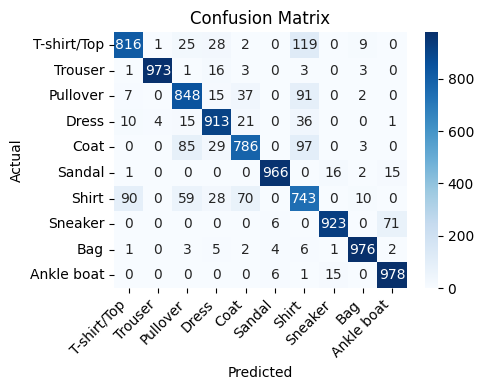

In [10]:
predicted_classes = np.argmax(model.predict(X_test),axis=1)

cm = confusion_matrix(y_test,predicted_classes)


plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=class_names,yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.xticks(rotation=45,ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show

print(classification_report(y_test , predicted_classes , target_names=class_names))

# Test on specific image

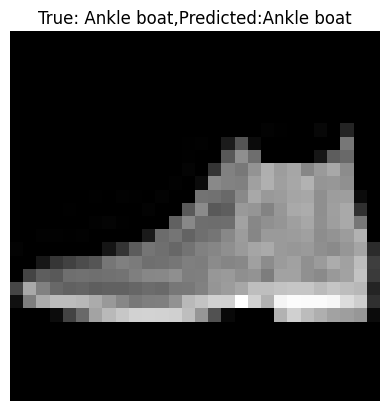

In [11]:
index = 0
plt.imshow(X_test[index].reshape(28,28),cmap="grey")
plt.title(f"True: {class_names[y_test[index]]},Predicted:{class_names[predicted_classes[index]]}")
plt.axis("off")
plt.show()

In [12]:
# Save the model
model.save('fashion_mnist_cnn.keras')
print("Model saved as fashion_mnist_cnn.keras")

Model saved as fashion_mnist_cnn.keras
